In [6]:
# state or schema. A langgraph schema resembles a python dataclass object
# can use @dataclass or pydantic BaseModel
%%capture --no-stderr
%pip install --quiet -U langgraph

LangGraph is the workflow component of a langchain agent-server application.
Just like Airflow is an optional component in a cloud server client application.

Graph:
State: Schema, corresponds to table in postgres\

Nodes: takes an input returns an output. Python fn.

Edges:conditional branch or fixed edge. Next state for workflow.

Pregel and Apache Beam are the runtimes underneath LangGraph. Pregel is named after the google distributed pregel graph engine but they are not the same. The google Pregel was never open sourced.

When and how graph state is written determines the stability of the runtime. It is wise to spend some time examining consistency issues before problems arise.

There are 4 steps to a graph update:

```
[Phase A: PLAN]  --> Reads immutable snapshot; checks channel versions/triggers
         │
         ▼
  [Phase B: EXECUTE] --> Runs all eligible nodes in parallel (concurrent futures)
         │
         ▼
  [Phase C: UPDATE]  --> Applies reducers at the barrier; increments channel versions
         │
         ▼
 [Phase D: CHECKPOINT]--> Persists step state via checkpointer; loops or terminates

```

A barrier is a threaded construct which waits for the longest thread to finish before proceeding.



In [22]:
from typing_extensions import TypedDict
from dataclasses import dataclass


@dataclass
class Address:
    number: int
    street: str
    city: str
    state: str


@dataclass
class Email:
    name: str
    age: int
    address: Address


address = Address(number=123, street="Main Street", city="San Jose", state="CA")
email = Email(name="Alice", age=32, address=address)

In [20]:
# making a graph. States are dataclasses as we saw above
# we are defining node functions

from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class GraphState(TypedDict, total=False):
    node_1_result: str
    node_2_result: str
    node_3_result: str


# python fn
def node_1(state: GraphState):
    print("node1")
    return {"node_1_result": "node1 completed"}


def node_2(state: GraphState):
    print("node2")
    return {"node2_result": "node2 completed"}


def node_3(state: GraphState):
    print("node3")
    return {"node3_result": "node3_completed"}


builder = StateGraph(GraphState)

builder.add_node(node_1)
builder.add_node(node_2)
builder.add_node(node_3)

# can alias
# builder.add_node("node1",node_1)
# builder.add_node("node2",node_2)
# builder.add_node("node3",node_3)
# builder.add_edge(START, "node1")
# builder.add_edge("node1", "node2")
# builder.add_edge("node1", "node3")
# builder.add_edge("node2", END)
# builder.add_edge("node3", END)
# g = builder.compile()
# result = g.invoke({})
# print(result)

builder.add_edge(START, "node_1")
# these execute in parallel
# race condition
# If both parallel nodes returned {"name": ...}, LangGraph INVALID_CONCURRENT_GRAPH_UPDATE,
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)
print(builder.nodes.keys())

# this remains in memory, There is no postgressql write.
g = builder.compile()
# a thread and checkpoint are needed for db persistence

result = graph.invoke({})
print(result)

node1
node2
node3
None


In [23]:
%pip install -U langgraph langgraph-checkpoint-postgres "psycopg[binary,pool]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.0 MB/s eta 0:00:00


Editorial: I disagree with the langgraph materials. The graphs are in a multithreaded env and writing the checkpointing option, which we have already decided is necessary for an audit trail,  in a context manager makes it clearer where we need to apply locks.



In [1]:
import threading
import uuid

from contextlib import contextmanager
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END


class GraphState(TypedDict, total=False):
    node_1_result: str
    node_2_result: str
    node_3_result: str


def node_1(state: GraphState):
    print("node 1")
    return {"node_1_result": "node 1 completed"}


def node_2(state: GraphState):
    print("node 2")
    return {"node_2_result": "node 2 completed"}


def node_3(state: GraphState):
    print("node 3")
    return {"node_3_result": "node 3 completed"}


# Build the graph.
builder = StateGraph(GraphState)

# Function names become node names automatically.
builder.add_node(node_1)
builder.add_node(node_2)
builder.add_node(node_3)

builder.add_edge(START, "node_1")

# node_2 and node_3 execute in parallel.
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")

builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

print("Registered nodes:", builder.nodes.keys())


@contextmanager
def managed_checkpointer(db_uri: str | None = None):
    """
    Create a checkpointer and a process-local operation lock.

    If db_uri is None, use InMemorySaver.
    Otherwise, use PostgresSaver.
    """
    operation_lock = threading.RLock()

    if db_uri is None:
        saver = InMemorySaver()

        try:
            yield saver, operation_lock
        finally:
            # InMemorySaver currently requires no cleanup.
            pass

    else:
        # Lazy import allows the in-memory example to work without
        # installing the PostgreSQL checkpoint package.
        from langgraph.checkpoint.postgres import PostgresSaver

        with PostgresSaver.from_conn_string(db_uri) as saver:
            saver.setup()
            yield saver, operation_lock


# Every thread_id identifies a separate checkpoint history.
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "thread_id": thread_id,
    }
}


# No URI means InMemorySaver will be used.
with managed_checkpointer() as (checkpointer, operation_lock):
    graph = builder.compile(checkpointer=checkpointer)

    # This lock is unnecessary for this single invocation, but it
    # establishes a boundary for future concurrent callers.
    with operation_lock:
        result = graph.invoke({}, config=config)

    print("\nFinal result:")
    print(result)

    with operation_lock:
        history = list(graph.get_state_history(config))

    print("\nCheckpoint history:")

    # History is returned newest first.
    for snapshot in reversed(history):
        print("-" * 60)
        print("Created:", snapshot.created_at)
        print("Step:", snapshot.metadata.get("step"))
        print("Source:", snapshot.metadata.get("source"))
        print("State:", snapshot.values)
        print("Next nodes:", snapshot.next)
        print("Tasks:", snapshot.tasks)

Registered nodes: dict_keys(['node_1', 'node_2', 'node_3'])
node 1
node 2
node 3

Final result:
{'node_1_result': 'node 1 completed', 'node_2_result': 'node 2 completed', 'node_3_result': 'node 3 completed'}

Checkpoint history:
------------------------------------------------------------
Created: 2026-09-10T18:59:42.186903+00:00
Step: -1
Source: input
State: {}
Next nodes: ('__start__',)
Tasks: (PregelTask(id='87147ca1-0a6a-e103-76bc-14dc30788cd4', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={}),)
------------------------------------------------------------
Created: 2026-09-10T18:59:42.200584+00:00
Step: 0
Source: loop
State: {}
Next nodes: ('node_1',)
Tasks: (PregelTask(id='e12f6907-cb32-059a-d575-b0e7380b8527', name='node_1', path=('__pregel_pull', 'node_1'), error=None, interrupts=(), state=None, result={'node_1_result': 'node 1 completed'}),)
------------------------------------------------------------
Created: 2026-09-10T18

In [2]:
# testing concurrency, two threads

import threading
import time
import uuid

from concurrent.futures import ThreadPoolExecutor
from contextlib import contextmanager
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END


class CounterState(TypedDict, total=False):
    counter: int


# Used only to force the race-condition demonstration.
race_barrier = None


def increment_counter(state: CounterState):
    current_value = state.get("counter", 0)

    print(f"{threading.current_thread().name} read counter={current_value}")

    # During the unlocked test, force both invocations to read
    # the old value before either writes its update.
    if race_barrier is not None:
        race_barrier.wait()

    time.sleep(0.1)

    new_value = current_value + 1

    print(f"{threading.current_thread().name} returns counter={new_value}")

    return {"counter": new_value}


builder = StateGraph(CounterState)
builder.add_node("increment", increment_counter)
builder.add_edge(START, "increment")
builder.add_edge("increment", END)


@contextmanager
def managed_checkpointer():
    checkpointer = InMemorySaver()
    operation_lock = threading.RLock()

    try:
        yield checkpointer, operation_lock
    finally:
        pass


def make_config():
    return {"configurable": {"thread_id": str(uuid.uuid4())}}


with managed_checkpointer() as (checkpointer, operation_lock):
    graph = builder.compile(checkpointer=checkpointer)

    # ---------------------------------------------------------
    # Test 1: concurrent invocations WITHOUT operation_lock
    # ---------------------------------------------------------

    unlocked_config = make_config()

    # Initialize the thread. The graph increments 0 to 1.
    graph.invoke({"counter": 0}, config=unlocked_config)

    # Force both concurrent invocations to read counter=1.
    race_barrier = threading.Barrier(2)

    def invoke_without_lock():
        return graph.invoke({}, config=unlocked_config)["counter"]

    with ThreadPoolExecutor(max_workers=2) as executor:
        unlocked_results = list(executor.map(lambda _: invoke_without_lock(), range(2)))

    race_barrier = None

    unlocked_final = graph.get_state(unlocked_config).values["counter"]

    print("\nWITHOUT LOCK")
    print("Individual results:", unlocked_results)
    print("Final counter:", unlocked_final)
    print("Expected counter:", 3)
    print("Lost update:", unlocked_final != 3)

    # ---------------------------------------------------------
    # Test 2: concurrent invocations WITH operation_lock
    # ---------------------------------------------------------

    locked_config = make_config()

    # Initialize another thread. The graph increments 0 to 1.
    graph.invoke({"counter": 0}, config=locked_config)

    def invoke_with_lock():
        with operation_lock:
            return graph.invoke({}, config=locked_config)["counter"]

    with ThreadPoolExecutor(max_workers=2) as executor:
        locked_results = list(executor.map(lambda _: invoke_with_lock(), range(2)))

    with operation_lock:
        locked_final = graph.get_state(locked_config).values["counter"]

    print("\nWITH LOCK")
    print("Individual results:", locked_results)
    print("Final counter:", locked_final)
    print("Expected counter:", 3)
    print("Lost update:", locked_final != 3)

MainThread read counter=0
MainThread returns counter=1
ThreadPoolExecutor-3_0 read counter=1
ThreadPoolExecutor-3_1 read counter=1
ThreadPoolExecutor-3_1 returns counter=2
ThreadPoolExecutor-3_0 returns counter=2

WITHOUT LOCK
Individual results: [2, 2]
Final counter: 2
Expected counter: 3
Lost update: True
MainThread read counter=0
MainThread returns counter=1
ThreadPoolExecutor-7_0 read counter=1
ThreadPoolExecutor-7_0 returns counter=2
ThreadPoolExecutor-7_1 read counter=2
ThreadPoolExecutor-7_1 returns counter=3

WITH LOCK
Individual results: [2, 3]
Final counter: 3
Expected counter: 3
Lost update: False


#Reducers


Source: langchain docs

Each key in the State dict has its own reducer. If there is no reducer defined then any update to the key will update and erase the old value. If there is no checkpointer, there is no way to recover this which has implications for audit trail functionality.  

Use append-only application logs and/or LangSmith traces because checkpoints may be deleted, expired, or administratively modified. When running through Agent Server, it injects and manages the database checkpointer automatically.


##Default Reducer:

Every reducer is a binary function with two positional arguments:

Left argument: The current value already stored in state for that key.

Right argument: The update for that key returned by a node.



In [ ]:
# a simple reducer example.
# should we add how ot reset the key to 0?
#
from operator import add
from typing import Annotated


class State(TypedDict):
    foo: Annotated[list[int], add]


def node_1(state):
    print("---Node 1---")
    return {"foo": [state["foo"][0] + 1]}


# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

result = graph.invoke()
print(result)

#Custom Reducers

Always bound the length of python lists or any other data structure if possible. This makes hunting down OOM errors later easier to reason about.



In [4]:
# a custom reducer
# a custom reducer is a function(posleft, posright) It is
#


def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right


class DefaultState(TypedDict):
    foo: Annotated[list[int], add]  # read list of avail reducers


class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]  # custom reducer

In [5]:
import hashlib
import json
import sqlite3
import threading
import uuid

from contextlib import contextmanager
from datetime import datetime, timezone
from operator import add
from pathlib import Path
from typing import Annotated, TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END


# ============================================================
# Configuration
# ============================================================

MAX_RECENT_EVENTS = 100

# The file survives until the Colab runtime is destroyed.
AUDIT_DB_PATH = Path(f"/tmp/langgraph-audit-{uuid.uuid4().hex}.sqlite")


# ============================================================
# Bounded graph-state reducer
# ============================================================


def keep_latest_events(
    current: list[dict] | None,
    updates: list[dict] | None,
) -> list[dict]:
    current = [] if current is None else current
    updates = [] if updates is None else updates

    return (current + updates)[-MAX_RECENT_EVENTS:]


# ============================================================
# Append-only audit store
# ============================================================


class SQLiteAuditStore:
    def __init__(self, path: Path):
        self.path = path
        self.lock = threading.RLock()

        self.connection = sqlite3.connect(
            path,
            check_same_thread=False,
        )

        self.connection.execute("""
            CREATE TABLE IF NOT EXISTS audit_events (
                sequence INTEGER PRIMARY KEY AUTOINCREMENT,
                event_id TEXT NOT NULL UNIQUE,
                created_at TEXT NOT NULL,
                payload_json TEXT NOT NULL,
                previous_hash TEXT NOT NULL,
                record_hash TEXT NOT NULL
            )
        """)

        # Prevent normal UPDATE and DELETE operations.
        self.connection.execute("""
            CREATE TRIGGER IF NOT EXISTS prevent_audit_update
            BEFORE UPDATE ON audit_events
            BEGIN
                SELECT RAISE(ABORT, 'audit records cannot be updated');
            END
        """)

        self.connection.execute("""
            CREATE TRIGGER IF NOT EXISTS prevent_audit_delete
            BEFORE DELETE ON audit_events
            BEGIN
                SELECT RAISE(ABORT, 'audit records cannot be deleted');
            END
        """)

        self.connection.commit()

    @staticmethod
    def calculate_hash(
        sequence: int,
        event_id: str,
        created_at: str,
        payload_json: str,
        previous_hash: str,
    ) -> str:
        canonical_record = json.dumps(
            {
                "sequence": sequence,
                "event_id": event_id,
                "created_at": created_at,
                "payload_json": payload_json,
                "previous_hash": previous_hash,
            },
            sort_keys=True,
            separators=(",", ":"),
        )

        return hashlib.sha256(canonical_record.encode("utf-8")).hexdigest()

    def append(self, event: dict) -> dict:
        event_id = event["event_id"]

        payload_json = json.dumps(
            event,
            sort_keys=True,
            separators=(",", ":"),
        )

        with self.lock:
            # Make retries idempotent.
            existing = self.connection.execute(
                """
                SELECT sequence, payload_json, record_hash
                FROM audit_events
                WHERE event_id = ?
                """,
                (event_id,),
            ).fetchone()

            if existing is not None:
                sequence, stored_payload, record_hash = existing

                if stored_payload != payload_json:
                    raise ValueError(
                        f"Event {event_id!r} was retried with different data"
                    )

                return {
                    "sequence": sequence,
                    "record_hash": record_hash,
                    "duplicate": True,
                }

            previous = self.connection.execute(
                """
                SELECT sequence, record_hash
                FROM audit_events
                ORDER BY sequence DESC
                LIMIT 1
                """
            ).fetchone()

            if previous is None:
                sequence = 1
                previous_hash = "GENESIS"
            else:
                sequence = previous[0] + 1
                previous_hash = previous[1]

            created_at = datetime.now(timezone.utc).isoformat()

            record_hash = self.calculate_hash(
                sequence,
                event_id,
                created_at,
                payload_json,
                previous_hash,
            )

            with self.connection:
                self.connection.execute(
                    """
                    INSERT INTO audit_events (
                        sequence,
                        event_id,
                        created_at,
                        payload_json,
                        previous_hash,
                        record_hash
                    )
                    VALUES (?, ?, ?, ?, ?, ?)
                    """,
                    (
                        sequence,
                        event_id,
                        created_at,
                        payload_json,
                        previous_hash,
                        record_hash,
                    ),
                )

            return {
                "sequence": sequence,
                "record_hash": record_hash,
                "duplicate": False,
            }

    def verify(self, expected_event_ids: list[str]) -> dict:
        with self.lock:
            rows = self.connection.execute(
                """
                SELECT
                    sequence,
                    event_id,
                    created_at,
                    payload_json,
                    previous_hash,
                    record_hash
                FROM audit_events
                ORDER BY sequence
                """
            ).fetchall()

        previous_hash = "GENESIS"
        actual_event_ids = []

        for expected_sequence, row in enumerate(rows, start=1):
            (
                sequence,
                event_id,
                created_at,
                payload_json,
                stored_previous_hash,
                stored_record_hash,
            ) = row

            calculated_hash = self.calculate_hash(
                sequence,
                event_id,
                created_at,
                payload_json,
                stored_previous_hash,
            )

            assert sequence == expected_sequence, (
                f"Sequence gap at record {expected_sequence}"
            )

            assert stored_previous_hash == previous_hash, (
                f"Broken hash chain at sequence {sequence}"
            )

            assert stored_record_hash == calculated_hash, (
                f"Modified record at sequence {sequence}"
            )

            actual_event_ids.append(event_id)
            previous_hash = stored_record_hash

        assert actual_event_ids == expected_event_ids, (
            "Audit log has missing, duplicated, or reordered events"
        )

        return {
            "valid": True,
            "event_count": len(rows),
            "head_hash": previous_hash,
        }

    def close(self):
        self.connection.close()


# ============================================================
# LangGraph state
# ============================================================


class GraphState(TypedDict, total=False):
    incoming_event: dict

    # Only the latest 100 are kept in active graph state.
    recent_events: Annotated[
        list[dict],
        keep_latest_events,
    ]

    # These fields connect the checkpoint to the audit chain.
    audit_count: int
    audit_head_hash: str


# ============================================================
# Managed resources
# ============================================================


@contextmanager
def managed_checkpointer():
    saver = InMemorySaver()

    try:
        yield saver
    finally:
        pass


@contextmanager
def managed_audit_store(path: Path):
    store = SQLiteAuditStore(path)

    try:
        yield store
    finally:
        store.close()


# ============================================================
# Run the example
# ============================================================

with managed_audit_store(AUDIT_DB_PATH) as audit_store:

    def archive_event(state: GraphState):
        """
        Archive the complete event before placing it in bounded state.
        """
        audit_result = audit_store.append(state["incoming_event"])

        return {
            "audit_count": audit_result["sequence"],
            "audit_head_hash": audit_result["record_hash"],
        }

    def add_to_recent_state(state: GraphState):
        return {"recent_events": [state["incoming_event"]]}

    builder = StateGraph(GraphState)

    builder.add_node("archive_event", archive_event)
    builder.add_node("add_to_recent_state", add_to_recent_state)

    builder.add_edge(START, "archive_event")
    builder.add_edge("archive_event", "add_to_recent_state")
    builder.add_edge("add_to_recent_state", END)

    with managed_checkpointer() as checkpointer:
        graph = builder.compile(checkpointer=checkpointer)

        config = {"configurable": {"thread_id": str(uuid.uuid4())}}

        expected_event_ids = []
        checkpoint_milestones = {}

        # Process more events than the active-state limit.
        for number in range(1, 121):
            event = {
                "event_id": f"event-{number:03d}",
                "event_number": number,
                "message": f"Audit event number {number}",
            }

            expected_event_ids.append(event["event_id"])

            graph.invoke(
                {
                    "incoming_event": event,
                    # Initialize the reducer on the first invocation.
                    **({"recent_events": []} if number == 1 else {}),
                },
                config=config,
            )

            # Capture checkpoints around the boundary.
            if number in {99, 100, 101, 120}:
                snapshot = graph.get_state(config)

                checkpoint_milestones[number] = {
                    "checkpoint_id": snapshot.config["configurable"]["checkpoint_id"],
                    "recent_count": len(snapshot.values["recent_events"]),
                    "audit_count": snapshot.values["audit_count"],
                    "audit_head_hash": snapshot.values["audit_head_hash"],
                }

        latest = graph.get_state(config)

        # Verify that no audit records were lost or modified.
        audit_result = audit_store.verify(expected_event_ids)

        # Verify that the latest checkpoint agrees with the audit store.
        assert latest.values["audit_count"] == audit_result["event_count"]
        assert latest.values["audit_head_hash"] == audit_result["head_hash"]

        print("Checkpoint milestones:")

        for event_number, milestone in checkpoint_milestones.items():
            print(event_number, milestone)

        print("\nFinal active-state size:")
        print(len(latest.values["recent_events"]))

        print("\nOldest active event:")
        print(latest.values["recent_events"][0]["event_id"])

        print("\nNewest active event:")
        print(latest.values["recent_events"][-1]["event_id"])

        print("\nAudit verification:")
        print(audit_result)

        print("\nAudit database:")
        print(AUDIT_DB_PATH)

Checkpoint milestones:
99 {'checkpoint_id': '1f1ad4f4-32da-6123-818a-464f2e35fdc1', 'recent_count': 99, 'audit_count': 99, 'audit_head_hash': '43c44fbd8a976f7b0fe44cbb21f6cd0a2932044cfc908fb824554ed0740a8112'}
100 {'checkpoint_id': '1f1ad4f4-32f6-6d45-818e-20b845d9f7f9', 'recent_count': 100, 'audit_count': 100, 'audit_head_hash': '454e68acaeeb045117b7029e6220d6a529eb18eb9df13c6eabc7eaee521e499e'}
101 {'checkpoint_id': '1f1ad4f4-3314-6a9d-8192-7c93ef4923bb', 'recent_count': 100, 'audit_count': 101, 'audit_head_hash': 'e6101dde36376df0901032a52b2c4f0e6d9104c27ad7123749b9c6867fefa05c'}
120 {'checkpoint_id': '1f1ad4f4-3559-62cc-81de-554d567161cd', 'recent_count': 100, 'audit_count': 120, 'audit_head_hash': 'c13ff65ec9d7cd852a3aca78013f23eb2e9ad062c7ba9d4a1cf6ff3b20590f1c'}

Final active-state size:
100

Oldest active event:
event-021

Newest active event:
event-120

Audit verification:
{'valid': True, 'event_count': 120, 'head_hash': 'c13ff65ec9d7cd852a3aca78013f23eb2e9ad062c7ba9d4a1cf6ff3

Large Objects. In ML/AI applictions it is common to have some large object, a large numpy or pytorch tensor. Could be a large OCR, a large image. Some data.

**We do not want to serialize this object or copy it around.**

Nodes in langgraph share the same process context. Example where 2 nodes share large object which is not in node memory space. The nodes are the control plane, The large numpy array is the data plane.



In [8]:
# If LangGraph is not installed, uncomment:
# %pip install -qU langgraph

import os
import threading

from dataclasses import dataclass
from typing import TypedDict

import numpy as np

from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime


# ------------------------------------------------------------
# Checkpointable graph state: only small results are stored here.
# ------------------------------------------------------------


class GraphState(TypedDict, total=False):
    left_sum: float
    right_sum: float
    total: float


# ------------------------------------------------------------
# Runtime context: holds the large array outside graph state.
# ------------------------------------------------------------


@dataclass
class RuntimeContext:
    large_array: np.ndarray


# ------------------------------------------------------------
# Parallel nodes
# ------------------------------------------------------------


def sum_left_half(
    state: GraphState,
    runtime: Runtime[RuntimeContext],
):
    array = runtime.context.large_array
    midpoint = array.size // 2

    print(
        "left:",
        "process =",
        os.getpid(),
        "thread =",
        threading.current_thread().name,
        "array address =",
        array.ctypes.data,
    )

    return {"left_sum": float(array[:midpoint].sum())}


def sum_right_half(
    state: GraphState,
    runtime: Runtime[RuntimeContext],
):
    array = runtime.context.large_array
    midpoint = array.size // 2

    print(
        "right:",
        "process =",
        os.getpid(),
        "thread =",
        threading.current_thread().name,
        "array address =",
        array.ctypes.data,
    )

    return {"right_sum": float(array[midpoint:].sum())}


def combine_results(state: GraphState):
    return {"total": state["left_sum"] + state["right_sum"]}


# ------------------------------------------------------------
# Build graph
# ------------------------------------------------------------

builder = StateGraph(
    GraphState,
    context_schema=RuntimeContext,
)

builder.add_node("sum_left_half", sum_left_half)
builder.add_node("sum_right_half", sum_right_half)
builder.add_node("combine_results", combine_results)

# Fan out: both summation nodes run in parallel.
builder.add_edge(START, "sum_left_half")
builder.add_edge(START, "sum_right_half")

# Fan in: combine waits for both nodes.
builder.add_edge(
    ["sum_left_half", "sum_right_half"],
    "combine_results",
)

builder.add_edge("combine_results", END)

graph = builder.compile()


# ------------------------------------------------------------
# Create one large shared array
# ------------------------------------------------------------

large_array = np.arange(
    5_000_000,
    dtype=np.float64,
)

# Protect against accidental writes by nodes.
large_array.flags.writeable = False

context = RuntimeContext(
    large_array=large_array,
)


# ------------------------------------------------------------
# Execute
# ------------------------------------------------------------

result = graph.invoke(
    {},
    context=context,
)

expected = float(large_array.sum())

print("\nGraph result:", result)
print("Expected total:", expected)
print("Result correct:", result["total"] == expected)
print(
    "Array size:",
    f"{large_array.nbytes / 1024**2:.2f} MiB",
)

left: process = 39814 thread = ThreadPoolExecutor-251_0 array address = 133853199831056
right: process = 39814 thread = ThreadPoolExecutor-251_1 array address = 133853199831056

Graph result: {'left_sum': 3124998750000.0, 'right_sum': 9374998750000.0, 'total': 12499997500000.0}
Expected total: 12499997500000.0
Result correct: True
Array size: 38.15 MiB


#Input Output Schemas, private State for internode communication



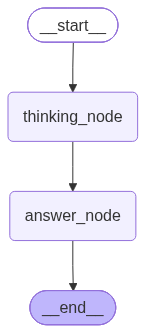

Thinking about: Hi
Private notes: The user's name is Lance.
Public result: {'answer': 'Hi Lance!'}


In [9]:
# convert pydantic to dataclasses for performance.

from dataclasses import dataclass

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END


# Public input accepted from the caller.
@dataclass
class InputState:
    question: str


# Public output returned to the caller.
@dataclass
class OutputState:
    answer: str


# Complete internal graph state.
@dataclass
class OverallState:
    question: str
    answer: str | None = None
    notes: str | None = None


def thinking_node(state: InputState):
    question = state.question

    print("Thinking about:", question)

    # Nodes normally return dictionaries containing state updates.
    return {"notes": "The user's name is Lance."}


def answer_node(state: OverallState):
    notes = state.notes

    print("Private notes:", notes)

    return {"answer": "Hi Lance!"}


builder = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState,
)

builder.add_node("thinking_node", thinking_node)
builder.add_node("answer_node", answer_node)

builder.add_edge(START, "thinking_node")
builder.add_edge("thinking_node", "answer_node")
builder.add_edge("answer_node", END)

graph = builder.compile()


# Visualize the graph.
display(Image(graph.get_graph().draw_mermaid_png()))


result = graph.invoke({"question": "Hi"})

print("Public result:", result)

##Messages
Messages are the communication mechanism between the system and the LLM. Send a resquest, get a response.

The material covers the issue of long messages leading to longer latency and higher cost. The bigger issue is a LLM in multi turn calls can't transfer context between calls so it has to append.

**As the context window fills up the LLM gets dumber. **

An applicaiton which works at initialization with a empty context window will fail as the context window fills up. This is one reason why evals are important at each step of application growth.



##Memory Selection Pipeline##

```
User message
   ↓
Privacy/security filter
   ↓
Memory relevance classifier
   ↓
Normalize into a durable fact
   ↓
Deduplicate against existing memories
   ↓
Embedding model converts text → numeric vector
   ↓
Vector database stores vector + text + metadata
```

```
memory = {
    "text": "The user prefers benchmark results in CSV format.",
    "memory_type": "preference",
    "user_id": "user-123",
    "source_message_id": "message-456",
    "confidence": 1.0,
}
```

In [16]:
%pip install --quiet -U langchain_core langgraph langchain-openai
from langchain_openai import ChatOpenAI
from google.colab import userdata
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(
    HumanMessage(
        f"Yes, I know about whales. But what others should I learn about?", name="Lance"
    )
)

for m in messages:
    m.pretty_print()
print("-------------")


openai_api_key = userdata.get("OPENAI_API_KEY")

if not openai_api_key:
    raise ValueError("Add OPENAI_API_KEY to the Colab Secrets panel.")


llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    api_key=openai_api_key,
    temperature=0,
)

messages = [HumanMessage(content="Hello! Introduce yourself briefly.")]

response = llm.invoke(messages)

print(response.content)

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
-------------
Hello! I am an AI digital assistant designed to help with a variety of tasks and provide information on a wide range of topics. I am here to assist you with any questions or tasks you may have. How can I help you today?


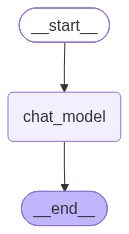

================================ Human Message =================================

Hello! Introduce yourself briefly.
================================== Ai Message ==================================

Hello! I am an AI digital assistant designed to help with a variety of tasks and provide information on a wide range of topics. I am here to assist you with any questions or tasks you may have. How can I help you today?


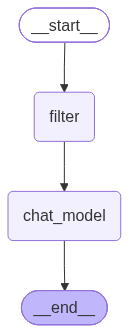

In [17]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END


# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}


# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


# trimming messages:
output = graph.invoke({"messages": messages})
for m in output["messages"]:
    m.pretty_print()


from langchain_core.messages import RemoveMessage


# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}


def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}


# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

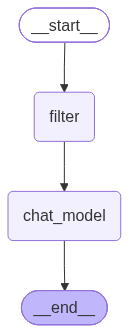


CURRENT MESSAGES
message-002 ai Hello Lance.
message-003 human Explain LangGraph memory.
lc_run--01a08d33-fcec-7f40-b3d3-2c57007dc4f3-0 ai LangGraph memory refers to the storage and retrieval of linguistic information in the LangGraph system. LangGraph is a computational model that represents language as a network of interconnected concepts and relationships. In this model, linguistic information is stored in the form of nodes (representing concepts) and edges (representing relationships between concepts).

The LangGraph memory system allows for efficient storage and retrieval of linguistic information. When a new piece of information is encountered, it is encoded into the LangGraph memory by creating new nodes and edges or updating existing ones. This allows the system to build a rich network of interconnected concepts over time.

When retrieving information from LangGraph memory, the system can use various algorithms to navigate the network and find relevant information. This allows

In [18]:
# removal of messages with audit trail, states who removed and why

import hashlib
import json
import operator
import uuid

from datetime import datetime, timezone
from typing import Annotated, TypedDict

from IPython.display import Image, display
from langchain_core.messages import RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END


class RemovalAuditEvent(TypedDict):
    event_id: str
    message_id: str
    message_type: str
    content_hash: str
    reason: str
    removed_by: str
    removed_at: str


class AuditedMessagesState(MessagesState):
    removal_audit: Annotated[
        list[RemovalAuditEvent],
        operator.add,
    ]


def hash_message_content(message) -> str:
    """
    Hash the content without copying the original message into
    the audit record.
    """
    canonical_content = json.dumps(
        message.content,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )

    return hashlib.sha256(canonical_content.encode("utf-8")).hexdigest()


def filter_messages(state: AuditedMessagesState):
    # Retain only the two most recent messages.
    messages_to_remove = state["messages"][:-2]

    delete_updates = []
    audit_events = []

    for message in messages_to_remove:
        if message.id is None:
            raise ValueError(
                "Every message must have an ID before it can be removed and audited."
            )

        delete_updates.append(RemoveMessage(id=message.id))

        audit_events.append(
            {
                "event_id": str(uuid.uuid4()),
                "message_id": str(message.id),
                "message_type": message.type,
                "content_hash": hash_message_content(message),
                "reason": "Keep only the two most recent messages",
                "removed_by": "filter_messages",
                "removed_at": datetime.now(timezone.utc).isoformat(),
            }
        )

    return {
        "messages": delete_updates,
        "removal_audit": audit_events,
    }


def chat_model_node(state: AuditedMessagesState):
    response = llm.invoke(state["messages"])

    return {"messages": [response]}


builder = StateGraph(AuditedMessagesState)

builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)


config = {"configurable": {"thread_id": "audited-message-thread"}}


display(Image(graph.get_graph().draw_mermaid_png()))


# Give messages explicit IDs so removal can be tracked.
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "My name is Lance.",
                "id": "message-001",
            },
            {
                "role": "assistant",
                "content": "Hello Lance.",
                "id": "message-002",
            },
            {
                "role": "user",
                "content": "Explain LangGraph memory.",
                "id": "message-003",
            },
        ],
        "removal_audit": [],
    },
    config=config,
)


print("\nCURRENT MESSAGES")

for message in result["messages"]:
    print(message.id, message.type, message.content)


print("\nREMOVAL AUDIT")

for event in result["removal_audit"]:
    print(event)


print("\nCHECKPOINT HISTORY")

history = list(graph.get_state_history(config))

for snapshot in reversed(history):
    print("-" * 60)
    print("Step:", snapshot.metadata.get("step"))
    print(
        "Message IDs:",
        [message.id for message in snapshot.values.get("messages", [])],
    )
    print(
        "Removal events:",
        snapshot.values.get("removal_audit", []),
    )